# Using sklearn Linear Regression Class:

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [37]:
df = pd.read_csv('placement.csv')

In [38]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

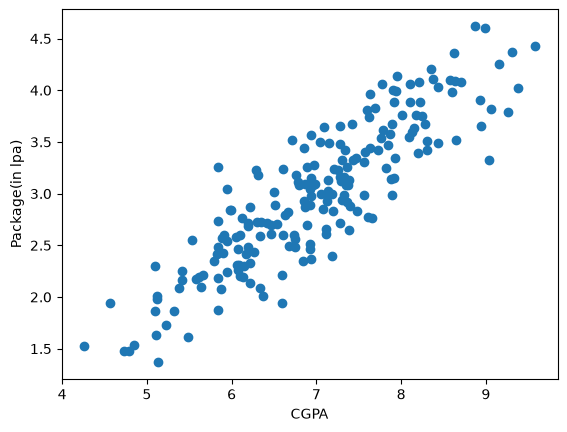

In [39]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [40]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [41]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [43]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
X_test


,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [44]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [45]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/home/zaid/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

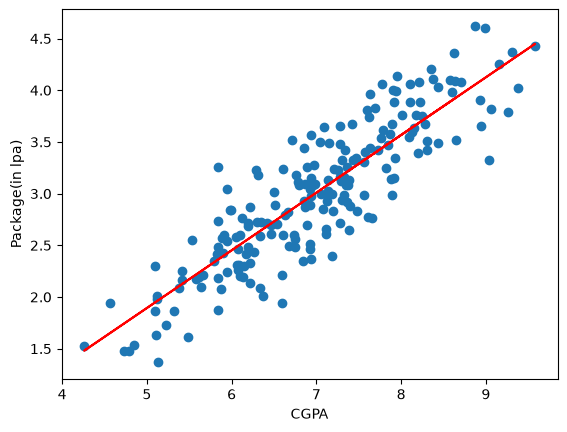

In [46]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [47]:
print("Slope (m): ",lr.coef_)
print("Intercept (b):", lr.intercept_)
m = lr.coef_
b = lr.intercept_

Slope (m):  [0.55795197]
Intercept (b): -0.8961119222429144


In [48]:
# y = mx + b
print(X_test.iloc[0].values.reshape(1,1))
print(m*X_test.iloc[0].values.reshape(1,1) + b)

[[8.58]]
[[3.89111601]]


In [49]:
print(X_test.iloc[1].values.reshape(1,1))
print(m*X_test.iloc[1].values.reshape(1,1) + b)

[[7.15]]
[[3.09324469]]


# Using Our own Class:

In [50]:
class MyLR:
    def __init__(self):
        self.m= None
        self.b = None
        
    def fit(self, X_train, y_train):
        num=0
        den=0
        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - X_train.mean())*(y_train[i]- y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)
        
    def predict(self, X_test):
        return self.m*X_test + self.b          

In [51]:
lr = MyLR()
lr.fit(X_train,y_train)
lr.predict(X_test[0])

KeyError: 0